# **IMPORTS**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# **lINE EQUATION**

## Line from two points

In [2]:
def line_from_points(p1, p2):
    """
    Compute line equation ax + by + c = 0 from two points.
    """
    x1, y1 = p1
    x2, y2 = p2

    a = y1 - y2
    
    b = x2 - x1
    c = x1 * y2 - x2 * y1

    return a, b, c

In [3]:
def print_line(L, name="Line"):
    a, b, c = L
    print(f"{name}: {a}x + {b}y + {c} = 0")

# **LINE INTERSECTION ANALYSIS**

## Intersection & Classification

In [4]:
def classify_and_intersect(L1, L2):
    """
    Classify two lines and compute intersection if exists.
    """
    a1, b1, c1 = L1
    a2, b2, c2 = L2

    D = a1 * b2 - a2 * b1

    # Parallel or identical
    if np.isclose(D, 0):
        #  check for identical lines
        if np.isclose(a1 * c2, a2 * c1) and np.isclose(b1 * c2, b2 * c1):
            return "identical", None
        else:
            return "parallel", None

    # Intersection
    x = (b1 * c2 - b2 * c1) / D
    y = (c1 * a2 - c2 * a1) / D

    return "intersecting", (x, y)

## Vector Analysis

In [5]:
def vector_analysis(v1, v2):
    """
    Compute dot product and cosine similarity for 2D or 3D vectors.
    """
    v1 = np.array(v1)
    v2 = np.array(v2)

    dot = np.dot(v1, v2)

    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)

    # Avoid division by zero
    if np.isclose(norm1, 0) or np.isclose(norm2, 0):
        cos_sim = 0
    else:
        cos_sim = dot / (norm1 * norm2)


    return dot, cos_sim

## Interpret Cosine

In [6]:
def interpret_cosine(cos):
    """
    Interpret cosine similarity.
    """
    if np.isclose(cos, 1):
        return "Same direction"
    elif np.isclose(cos, -1):
        return "Opposite direction"
    elif np.isclose(cos, 0):
        return "Orthogonal (90°)"
    elif cos > 0:
        return "Acute angle"
    else:
        return "Obtuse angle"

# **PLOT FUNCTIONS**

## Plot lines

In [7]:
import os

def get_next_filename(base_name, extension=".png"):
    folder = "output"
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    counter = 1
    while True:
        file_path = os.path.join(folder, f"{base_name}_{counter}{extension}")
        if not os.path.exists(file_path):
            return file_path
        counter += 1

In [8]:
def plot_lines(L1, L2, intersection=None):
    a1, b1, c1 = L1
    a2, b2, c2 = L2

    if intersection:
        margin = 10
        x_min = min(-10, intersection[0] - margin)
        x_max = max(10, intersection[0] + margin)
    else:
        x_min, x_max = -10, 10

    x = np.linspace(x_min, x_max, 400)
    plt.figure(figsize=(10, 7))

    # Line 1
    if not np.isclose(b1, 0):
        y1 = (-a1 * x - c1) / b1
        plt.plot(x, y1, label="Line 1", linewidth=2)
    else:
        plt.axvline(-c1 / a1, color='steelblue', label="Line 1 (Vertical)", linewidth=2)

    # Line 2
    if not np.isclose(b2, 0):
        y2 = (-a2 * x - c2) / b2
        plt.plot(x, y2, label="Line 2", linewidth=2)
    else:
        plt.axvline(-c2 / a2, color='orange', label="Line 2 (Vertical)", linewidth=2)

    # Intersection point
    if intersection:
        plt.scatter(*intersection, color="red", s=100, zorder=5, 
                    label=f"Intersection {np.round(intersection, 2)}")
        plt.axvline(intersection[0], color='gray', linestyle='--', alpha=0.3)
        plt.axhline(intersection[1], color='gray', linestyle='--', alpha=0.3)

    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linewidth=1)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.title("Analytical Geometry - Lines")
    
    save_path = get_next_filename("line_analysis")
    plt.savefig(save_path)
    plt.show()

## Plot vectors


In [9]:
def plot_vectors(v1, v2):
    is_3d = len(v1) == 3
    fig = plt.figure(figsize=(8, 8))
    
    if is_3d:
        ax = fig.add_subplot(111, projection='3d')
        ax.quiver(0, 0, 0, v1[0], v1[1], v1[2], color='red', label='Vector 1', arrow_length_ratio=0.15)
        ax.quiver(0, 0, 0, v2[0], v2[1], v2[2], color='blue', label='Vector 2', arrow_length_ratio=0.15)
        
        limit = max(np.linalg.norm(v1), np.linalg.norm(v2)) + 1
        ax.set_xlim([-limit, limit])
        ax.set_ylim([-limit, limit])
        ax.set_zlim([-limit, limit])
        ax.set_zlabel('Z')
    else:
        ax = fig.add_subplot(111)
        ax.quiver(0, 0, v1[0], v1[1], color='red', angles='xy', scale_units='xy', scale=1, label='Vector 1')
        ax.quiver(0, 0, v2[0], v2[1], color='blue', angles='xy', scale_units='xy', scale=1, label='Vector 2')
        
        limit = max(np.linalg.norm(v1), np.linalg.norm(v2)) + 1
        ax.set_xlim([-limit, limit])
        ax.set_ylim([-limit, limit])

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    plt.title(f"Vector Visualization ({'3D' if is_3d else '2D'})")

    prefix = "vector_3d" if is_3d else "vector_2d"
    save_path = get_next_filename(prefix)
    plt.savefig(save_path)
    plt.show()
    plt.close()


# **RUN FUNCTIONS**

In [10]:
def analyze_and_plot_lines(p1, p2, p3, p4):
   
    print("\n--- [ Lines Analysis ] ---")
    L1 = line_from_points(p1, p2)
    L2 = line_from_points(p3, p4)
    print_line(L1, "Line 1")
    print_line(L2, "Line 2")
    
    relation, point = classify_and_intersect(L1, L2)
    print(f"Relation: {relation}")
    if point:
        print(f"Intersection Point: ({point[0]:.2f}, {point[1]:.2f})")
    
    plot_lines(L1, L2, point)

In [11]:
def analyze_and_plot_vectors(v1, v2):
    
    print(f"\n--- [ {len(v1)}D Vector Analysis ] ---")
    dot, cos = vector_analysis(v1, v2)
    print(f"Vector 1: {v1} | Vector 2: {v2}")
    print(f"Dot Product: {dot}")
    print(f"Cosine Similarity: {cos:.4f}")
    print(f"Interpretation: {interpret_cosine(cos)}")
    
    plot_vectors(v1, v2)

# **OUTPUTS**


--- [ Lines Analysis ] ---
Line 1: -4x + 3y + -2 = 0
Line 2: 4x + 3y + -22 = 0
Relation: intersecting
Intersection Point: (2.50, 4.00)


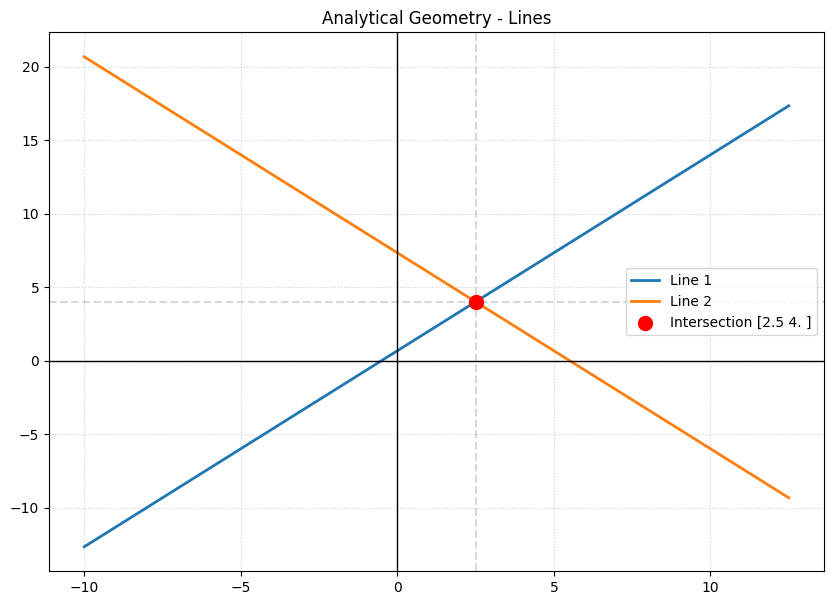

In [12]:
analyze_and_plot_lines(p1=(1, 2), p2=(4, 6), p3=(1, 6), p4=(4, 2))


--- [ Lines Analysis ] ---
Line 1: -4x + -8y + 28 = 0
Line 2: -3x + -8y + 4 = 0
Relation: intersecting
Intersection Point: (24.00, -8.50)


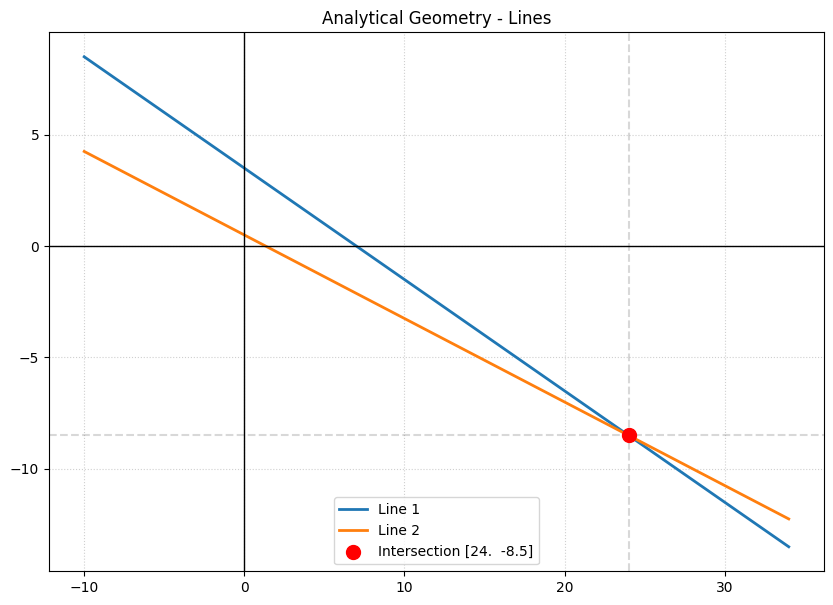

In [13]:
analyze_and_plot_lines(p1=(3, 2), p2=(-5, 6), p3=(4, -1), p4=(-4, 2))


--- [ 2D Vector Analysis ] ---
Vector 1: [3, 4] | Vector 2: [-4, 3]
Dot Product: 0
Cosine Similarity: 0.0000
Interpretation: Orthogonal (90°)


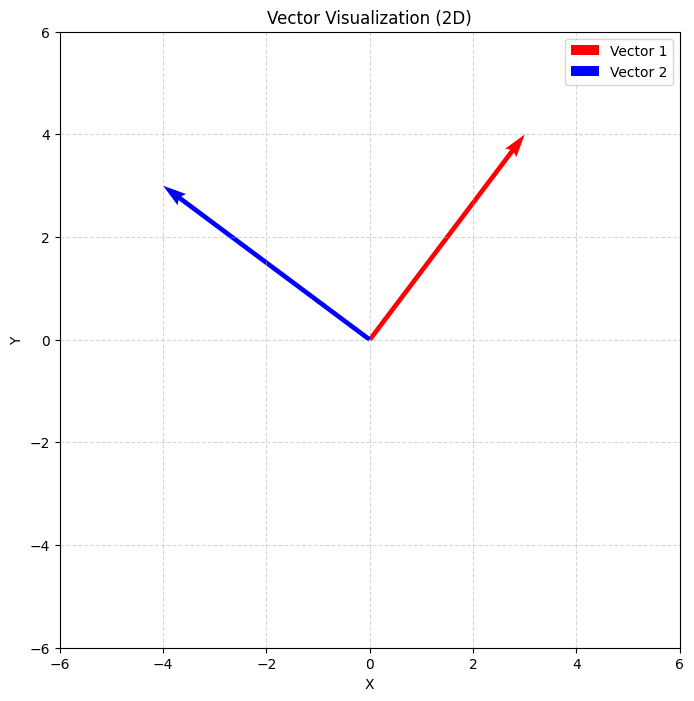

In [14]:
analyze_and_plot_vectors([3, 4], [-4, 3])


--- [ 2D Vector Analysis ] ---
Vector 1: [3, -1] | Vector 2: [-4, 3]
Dot Product: -15
Cosine Similarity: -0.9487
Interpretation: Obtuse angle


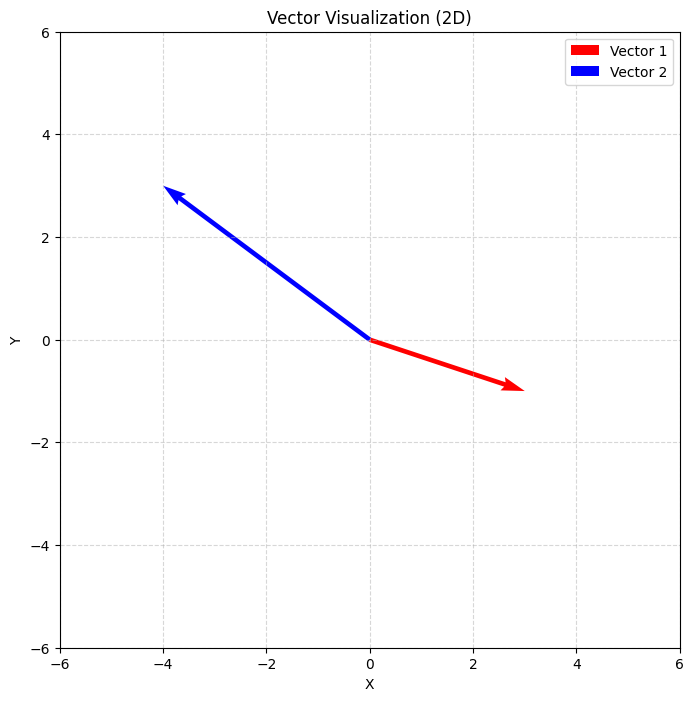

In [15]:
analyze_and_plot_vectors([3, -1], [-4, 3])


--- [ 2D Vector Analysis ] ---
Vector 1: [-5, -3] | Vector 2: [-4, 3]
Dot Product: 11
Cosine Similarity: 0.3773
Interpretation: Acute angle


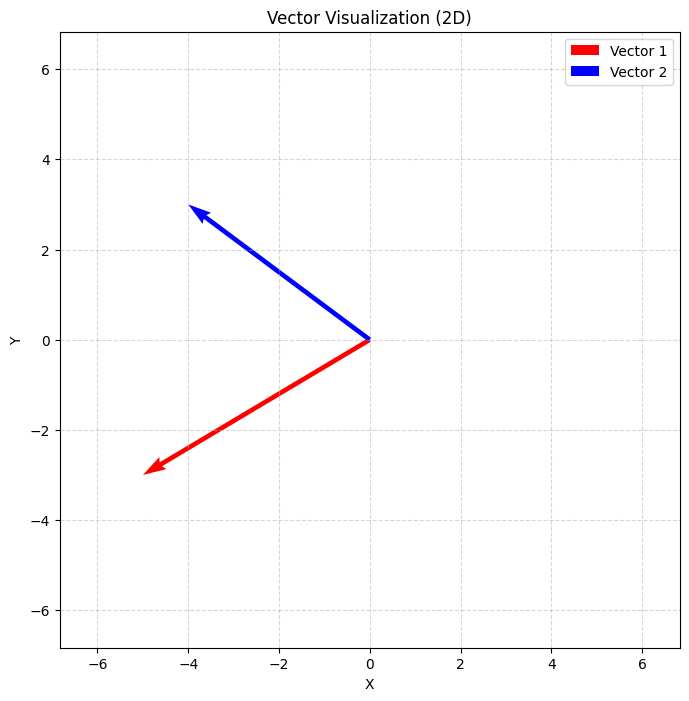

In [16]:
analyze_and_plot_vectors([-5, -3], [-4, 3])


--- [ 3D Vector Analysis ] ---
Vector 1: [1, 2, 3] | Vector 2: [2, 4, 6]
Dot Product: 28
Cosine Similarity: 1.0000
Interpretation: Same direction


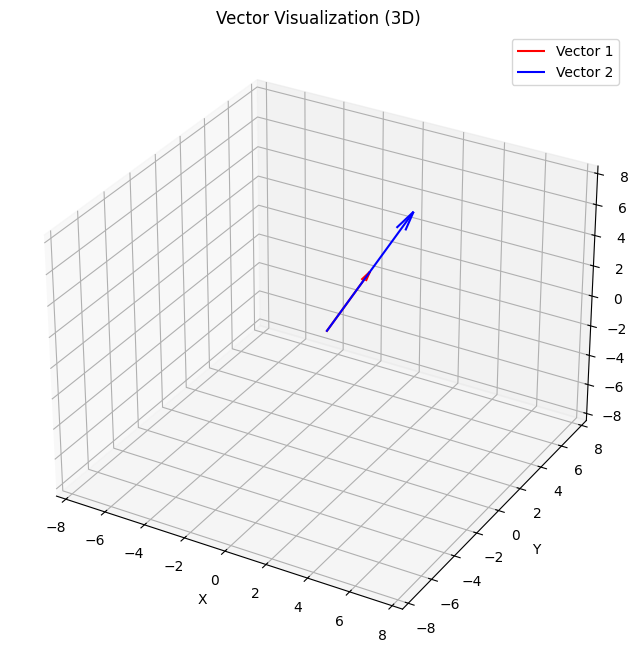

In [17]:
analyze_and_plot_vectors([1, 2, 3], [2, 4, 6])


--- [ 3D Vector Analysis ] ---
Vector 1: [-4, 2, 3] | Vector 2: [2, 5, 6]
Dot Product: 20
Cosine Similarity: 0.4607
Interpretation: Acute angle


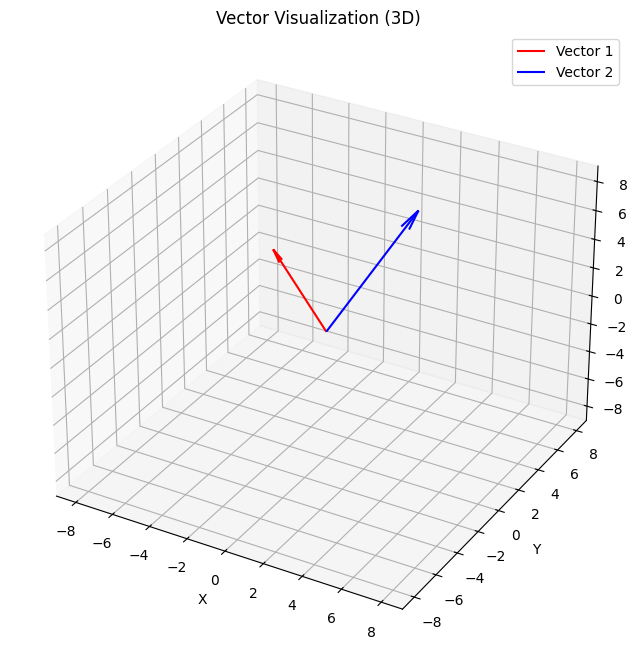

In [18]:
analyze_and_plot_vectors([-4, 2, 3], [2, 5, 6])


--- [ 3D Vector Analysis ] ---
Vector 1: [-4, -2, 7] | Vector 2: [-5, -1, -6]
Dot Product: -20
Cosine Similarity: -0.3058
Interpretation: Obtuse angle


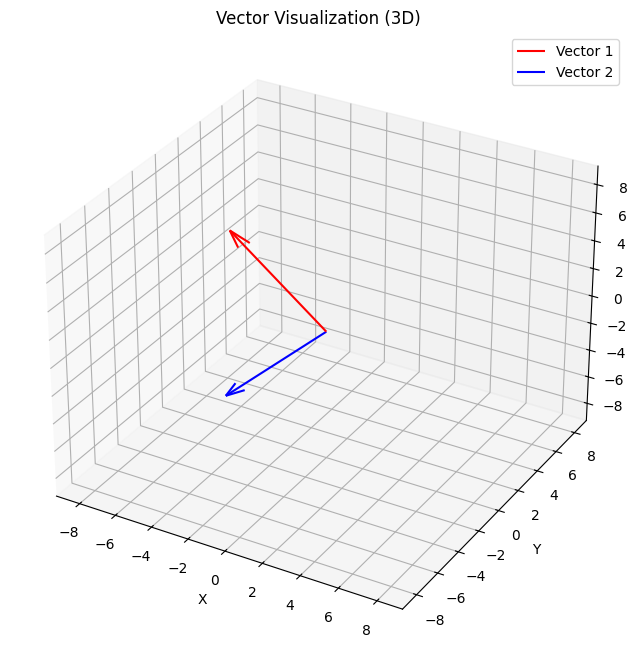

In [19]:
analyze_and_plot_vectors([-4, -2, 7], [-5, -1, -6])